# Aula 5 — SVD: truncamento e Eckart–Young
### Aproximações de baixa ordem, energia acumulada, gap espectral, compressão e remoção de ruído

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 5. A Aula 4 mostrou que $A=U\Sigma V^T$. Agora a
pergunta é: precisamos de **todos** os valores singulares? Em muitos dados a resposta é não — a
estrutura dominante está nos primeiros $\sigma_i$. Vamos construir a **SVD truncada** $A_k$,
verificar numericamente as fórmulas de erro, confirmar o **teorema de Eckart–Young**, escolher o
posto por **energia acumulada** e **gap espectral**, e aplicar a ideia em **compressão** e
**remoção de ruído**.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | SVD, normas, posto |
| `matplotlib` | 3.5 | curvas de $\sigma_i$, imagens, modos |

```bash
pip install numpy matplotlib
```

> Sem dependências opcionais e sem arquivos externos (a "imagem" é gerada sinteticamente).

In [1]:
# --- Imports concentrados ---
import numpy as np
import matplotlib.pyplot as plt

# Várias demonstrações geram dados aleatórios (matrizes de teste, ruído).
# Fixar a semente faz o notebook produzir SEMPRE os mesmos números, então os
# resultados que você vê aqui se repetem quando você roda de novo.
np.random.seed(42)


# Esta função monta a SVD truncada A_k. Definimos uma função porque ela é usada
# em quase todas as seções abaixo — escrever a mesma conta repetida seria pior.
def aproxima_posto(A, k):
    '''Aproximação SVD truncada de posto k: A_k = U_k Sigma_k V_k^T.'''
    # np.linalg.svd devolve A = U @ diag(s) @ Vt, já com os valores singulares s
    # ordenados do maior para o menor. full_matrices=False entrega U e Vt "finos"
    # (só as colunas/linhas úteis), que é o que precisamos para reconstruir.
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    # Truncar = ficar só com os k primeiros termos da soma sigma_i * u_i * v_i^T.
    #   U[:, :k]  -> as k primeiras colunas de U (os vetores u_1..u_k)
    #   s[:k]     -> os k primeiros valores singulares
    #   Vt[:k, :] -> as k primeiras linhas de Vt (os vetores v_1..v_k transpostos)
    # O "U[:, :k] * s[:k]" usa BROADCASTING: cada coluna i de U é multiplicada
    # pelo escalar s[i] correspondente (equivale a U_k @ diag(s_k), só que sem
    # construir a matriz diagonal). Depois multiplicamos por Vt[:k, :] com "@".
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


print("Ambiente pronto.")

Ambiente pronto.


## Objetivos computacionais

1. Construir $A_k$ e ver a aproximação melhorar com $k$.
2. Verificar $\|A-A_k\|_F^2=\sum_{i>k}\sigma_i^2$ e $\|A-A_k\|_2=\sigma_{k+1}$.
3. Confirmar **Eckart–Young**: $A_k$ é a melhor matriz de posto $\le k$.
4. Escolher o posto por **energia acumulada** e **gap espectral**.
5. Aplicar em **compressão** de imagem e **remoção de ruído**; ler uma matriz de **snapshots**.

## 1. SVD truncada $A_k$

$A=\sum_{i=1}^r\sigma_i\mathbf{u}_i\mathbf{v}_i^T$; a truncada mantém os $k$ primeiros termos.
Para a diagonal $\operatorname{diag}(5,2,1)$, $A_1,A_2,A_3$ recuperam progressivamente a matriz
(Exemplos 1–2).

In [2]:
# Diagonal das notas: aproximações sucessivas.
# np.diag([...]) cria a matriz diagonal com esses números na diagonal principal.
A = np.diag([5.0, 2.0, 1.0])

# Para k = 1, 2, 3 montamos A_k e imprimimos. Espera-se ver A_1 com só o "5",
# A_2 com o "5" e o "2", e A_3 já igual à matriz original (Exemplos 1-2).
for k in [1, 2, 3]:
    # np.round só arredonda para a impressão ficar limpa (tira ruído numérico
    # tipo 4.99999999); não altera a conta.
    print(f"A_{k} =\n{np.round(aproxima_posto(A, k), 6)}\n")

# np.allclose compara duas matrizes "a menos de" erro de arredondamento.
print("A_3 == A ?", np.allclose(aproxima_posto(A, 3), A))

A_1 =
[[5. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

A_2 =
[[5. 0. 0.]
 [0. 2. 0.]
 [0. 0. 0.]]

A_3 =
[[5. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]

A_3 == A ? True


## 2. Erro de reconstrução (Eckart–Young, fórmulas)

$\|A-A_k\|_F^2=\sum_{i=k+1}^r\sigma_i^2$ e $\|A-A_k\|_2=\sigma_{k+1}$. Conferimos no
$\operatorname{diag}(5,2,1)$: $\|A-A_1\|_F=\sqrt5$, $\|A-A_1\|_2=2$, $\|A-A_2\|_2=1$ (Exemplo 3).

In [3]:
# Verificar as fórmulas de erro contra a SVD.
A = np.diag([5.0, 2.0, 1.0])

# compute_uv=False pede só os valores singulares (não calcula U nem V): mais barato.
s = np.linalg.svd(A, compute_uv=False)

for k in [1, 2]:
    Ak = aproxima_posto(A, k)

    # Erro medido de duas formas (as duas normas do teorema de Eckart-Young):
    erroF = np.linalg.norm(A - Ak, 'fro')   # norma de Frobenius
    erro2 = np.linalg.norm(A - Ak, 2)       # norma espectral (maior valor singular do erro)

    # As notas dizem que:
    #   ||A - A_k||_F = raiz da soma dos sigma_i^2 DESCARTADOS (os de índice > k)
    #   ||A - A_k||_2 = o primeiro sigma descartado, sigma_{k+1}
    # Em Python a indexação começa em 0, então:
    #   s[k:]  -> os valores singulares a partir da posição k (os descartados)
    #   s[k]   -> o valor singular sigma_{k+1} das notas (próximo a ser descartado)
    soma_descartados = np.sqrt(np.sum(s[k:]**2))
    print(f"k={k}: ||A-A_k||_F = {erroF:.6f} (sqrt(sum sigma_>k^2) = {soma_descartados:.6f})"
          f" | ||A-A_k||_2 = {erro2:.6f} (sigma_{k+1} = {s[k]:.6f})")

k=1: ||A-A_k||_F = 2.236068 (sqrt(sum sigma_>k^2) = 2.236068) | ||A-A_k||_2 = 2.000000 (sigma_2 = 2.000000)
k=2: ||A-A_k||_F = 1.000000 (sqrt(sum sigma_>k^2) = 1.000000) | ||A-A_k||_2 = 1.000000 (sigma_3 = 1.000000)


## 3. Eckart–Young: $A_k$ é a melhor de posto $\le k$

Geramos várias matrizes **aleatórias** de posto $k$ e comparamos seu erro com o de $A_k$. Nenhuma
deve superar (ter erro menor que) a aproximação SVD.

erro SVD (A_k)        = 2.5575
menor erro aleatório  = 8.5013  (>= erro SVD)
Eckart–Young respeitado? True


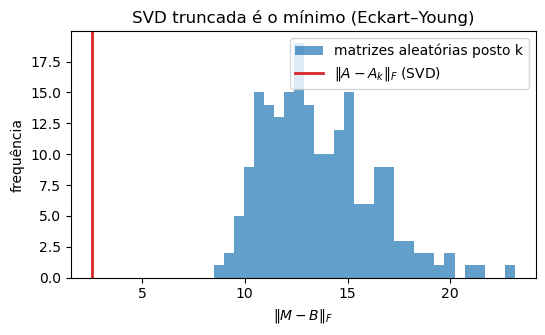

In [4]:
# Comparar A_k com matrizes aleatórias de posto k.
M = np.random.randn(8, 6)             # matriz "cheia" qualquer (8x6, entradas aleatórias)
k = 3
Ak = aproxima_posto(M, k)             # a melhor de posto k segundo a SVD
erro_svd = np.linalg.norm(M - Ak, 'fro')

# Agora geramos MUITAS matrizes aleatórias de posto k e medimos o erro de cada uma.
# Truque para fabricar posto k: o produto de uma (8 x k) por uma (k x 6) tem posto
# no máximo k (a "cintura" k limita o posto). Pela teoria, nenhuma dessas pode ter
# erro menor do que A_k.
erros_rand = []
for _ in range(200):                  # "_" é uma variável descartável (não usamos o contador)
    B = np.random.randn(8, k) @ np.random.randn(k, 6)   # matriz aleatória de posto <= k
    erros_rand.append(np.linalg.norm(M - B, 'fro'))     # guarda o erro dessa tentativa
erros_rand = np.array(erros_rand)     # vira array para usar .min()

print(f"erro SVD (A_k)        = {erro_svd:.4f}")
print(f"menor erro aleatório  = {erros_rand.min():.4f}  (>= erro SVD)")
# Tolerância 1e-9 evita falso negativo por arredondamento.
print("Eckart–Young respeitado?", erros_rand.min() >= erro_svd - 1e-9)

# Histograma: todos os erros aleatórios ficam À DIREITA da linha vermelha (o erro
# da SVD), ilustrando que A_k é o mínimo.
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(erros_rand, bins=30, alpha=0.7, label="matrizes aleatórias posto k")
ax.axvline(erro_svd, color="tab:red", lw=2, label=r"$\|A-A_k\|_F$ (SVD)")
ax.set_xlabel(r"$\|M-B\|_F$"); ax.set_ylabel("frequência"); ax.legend()
ax.set_title("SVD truncada é o mínimo (Eckart–Young)"); plt.show()

## 4. Energia acumulada

$E_k=\dfrac{\sum_{i=1}^k\sigma_i^2}{\sum_i\sigma_i^2}$. Para $\sigma=(10,4,1,0.5)$ das notas,
$E_1\approx0.853$ e $E_2\approx0.989$ (logo $k=2$ já preserva $>95\%$).

E_1 = 0.8529
E_2 = 0.9893
E_3 = 0.9979
E_4 = 1.0000
menor k com E_k >= 0.95: 2


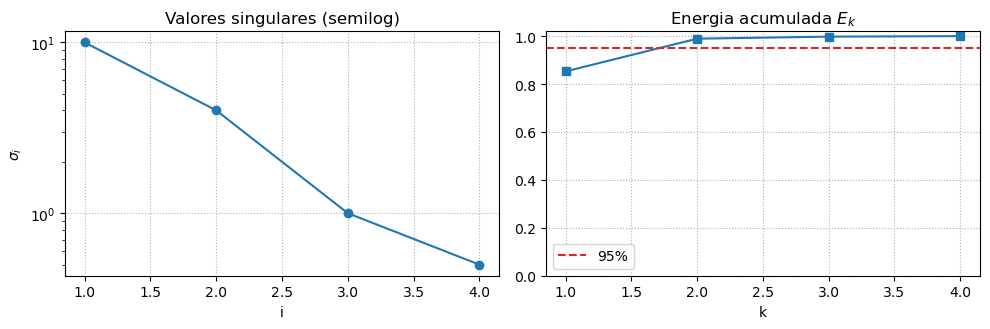

In [5]:
# Energia acumulada do exemplo das notas.
sig = np.array([10.0, 4.0, 1.0, 0.5])

# np.cumsum faz a SOMA ACUMULADA: [s0, s0+s1, s0+s1+s2, ...]. Aplicado a sig**2
# dá a energia somada até cada modo; dividir pela energia total (np.sum(sig**2))
# transforma em fração E_k = (sigma_1^2 + ... + sigma_k^2) / (soma de todos).
energia = np.cumsum(sig**2) / np.sum(sig**2)
for k in range(1, len(sig)+1):
    print(f"E_{k} = {energia[k-1]:.4f}")   # energia[k-1] porque o índice começa em 0

# np.searchsorted acha em que posição o valor 0.95 "entraria" no vetor energia
# (que é crescente). Isso dá o menor k cuja energia acumulada já alcança 95%.
k95 = int(np.searchsorted(energia, 0.95) + 1)
print("menor k com E_k >= 0.95:", k95)

# Dois gráficos lado a lado: à esquerda os sigma_i (em semilog, para ver a queda);
# à direita a energia acumulada com a linha de referência de 95%.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
indices = range(1, len(sig)+1)   # eixo x: 1, 2, 3, 4 (os índices dos modos)

ax1.semilogy(indices, sig, "o-")
ax1.set_title("Valores singulares (semilog)")
ax1.set_xlabel("i"); ax1.set_ylabel(r"$\sigma_i$"); ax1.grid(True, ls=":")

ax2.plot(indices, energia, "s-")
ax2.axhline(0.95, color="tab:red", ls="--", label="95%")   # linha horizontal de referência
ax2.set_title("Energia acumulada $E_k$")
ax2.set_xlabel("k"); ax2.set_ylim(0, 1.02); ax2.legend(); ax2.grid(True, ls=":")

plt.tight_layout(); plt.show()

## 5. Gap espectral e cotovelo

A razão $\sigma_i/\sigma_{i+1}$ grande indica um **gap**. Para $\sigma=(20,12,8,0.4,0.3)$,
$\sigma_3/\sigma_4=20$ marca a separação entre estrutura dominante e cauda (ruído).

sigma_1/sigma_2 = 1.67
sigma_2/sigma_3 = 1.50
sigma_3/sigma_4 = 20.00
sigma_4/sigma_5 = 1.33
maior gap após o índice: 3


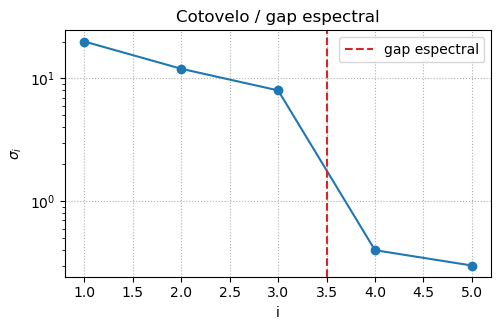

In [6]:
# Detectar o gap espectral pelas razões consecutivas.
sig = np.array([20.0, 12.0, 8.0, 0.4, 0.3])

# Queremos cada razão sigma_i / sigma_{i+1}. Em vez de um laço, alinhamos dois
# pedaços do vetor e dividimos elemento a elemento:
#   sig[:-1] = todos menos o ÚLTIMO  -> [20, 12, 8, 0.4]   (os sigma_i)
#   sig[1:]  = todos menos o PRIMEIRO -> [12, 8, 0.4, 0.3]  (os sigma_{i+1})
# A divisão casa as posições: 20/12, 12/8, 8/0.4, 0.4/0.3.
razoes = sig[:-1] / sig[1:]

# enumerate(razoes, start=1) percorre a lista entregando (i, valor) com i começando
# em 1, para os rótulos saírem como sigma_1/sigma_2, sigma_2/sigma_3, ...
for i, r in enumerate(razoes, start=1):
    print(f"sigma_{i}/sigma_{i+1} = {r:.2f}")

# np.argmax devolve a POSIÇÃO da maior razão; +1 ajusta para o índice do sigma.
print("maior gap após o índice:", int(np.argmax(razoes) + 1))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.semilogy(range(1, len(sig)+1), sig, "o-")
# Linha em x=3.5 (entre os índices 3 e 4): é onde a maior razão indica o gap.
ax.axvline(3.5, color="tab:red", ls="--", label="gap espectral")
ax.set_xlabel("i"); ax.set_ylabel(r"$\sigma_i$"); ax.set_title("Cotovelo / gap espectral")
ax.legend(); ax.grid(True, ls=":"); plt.show()

## 6. Compressão por SVD

Geramos uma "imagem" sintética com estrutura aproximadamente de baixo posto e a reconstruímos
para vários $k$. O custo de $A_k$ é $\approx k(m+n+1)$ números, contra $mn$ da matriz cheia.

In [7]:
# Imagem sintética (sem arquivos externos): poucos padrões + textura suave.
n = 120

# np.meshgrid monta duas GRADES 2D de coordenadas a partir de um eixo x e um eixo y:
# xx tem o valor de x em cada pixel e yy o valor de y. Com elas, qualquer fórmula
# f(xx, yy) é avaliada em TODOS os pixels de uma vez (sem dois laços encaixados).
xx, yy = np.meshgrid(np.linspace(-3, 3, n), np.linspace(-3, 3, n))

# A "imagem" é a soma de poucos padrões globais -> tem estrutura aproximadamente
# de baixo posto (é justamente o que a SVD vai explorar na compressão).
img = (np.exp(-(xx**2 + yy**2)/2)                 # blob central (gaussiana)
       + 0.6*np.sin(1.5*xx) * np.cos(1.5*yy)      # padrão ondulado
       + 0.3*np.exp(-((xx-1.5)**2 + (yy+1)**2)))  # segundo blob, deslocado
img += 0.02*np.random.randn(n, n)                 # textura leve (ruído fraco)

# Olhamos os maiores valores singulares: poucos grandes confirmam o baixo posto.
s = np.linalg.svd(img, compute_uv=False)
print("imagem:", img.shape, "| 6 maiores sigma:", np.round(s[:6], 2))

imagem: (120, 120) | 6 maiores sigma: [43.69 29.02  3.71  0.42  0.41  0.41]


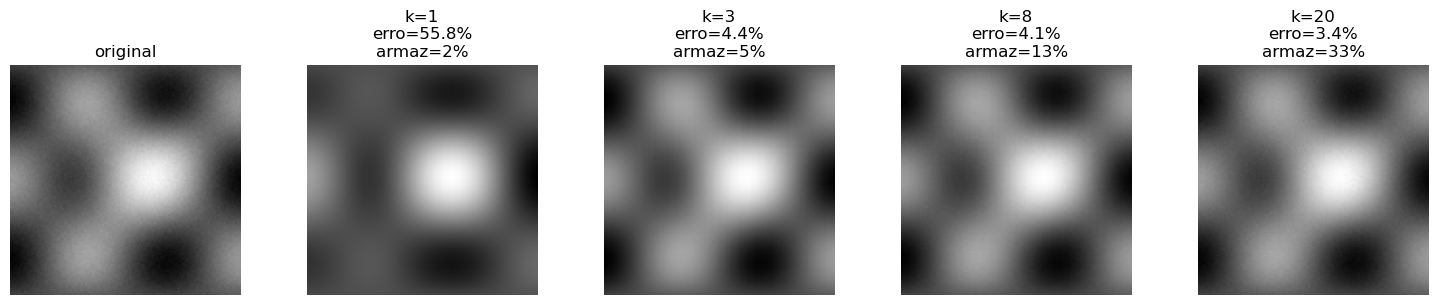

In [8]:
# Reconstruções para diferentes k.
ks = [1, 3, 8, 20]

# Um painel a mais que o número de k's: o primeiro mostra a imagem original.
fig, axes = plt.subplots(1, len(ks)+1, figsize=(3*(len(ks)+1), 3))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")

# zip(axes[1:], ks) anda em paralelo nos painéis (a partir do 2º) e nos valores de k:
# em cada volta pegamos um painel "ax" e um "k" juntos.
for ax, k in zip(axes[1:], ks):
    Ik = aproxima_posto(img, k)                                   # reconstrução de posto k
    erro = np.linalg.norm(img - Ik, 'fro') / np.linalg.norm(img, 'fro')   # erro relativo
    # Armazenamento de A_k = k*(m+n+1); aqui a imagem é nxn (m=n), logo k*(2n+1).
    # Dividido por n^2 (tamanho da imagem cheia) dá a FRAÇÃO de armazenamento.
    comp = k*(2*n + 1) / n**2
    ax.imshow(Ik, cmap="gray"); ax.axis("off")
    ax.set_title(f"k={k}\nerro={erro:.1%}\narmaz={comp:.0%}")   # ".1%" formata como porcentagem
plt.tight_layout(); plt.show()

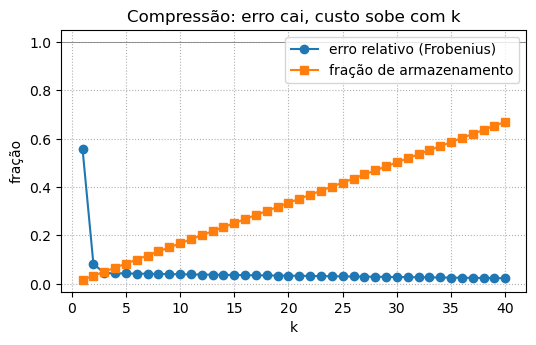

In [9]:
# Erro relativo e custo de armazenamento em função de k.
ks_all = np.arange(1, 41)   # np.arange(1, 41) gera os inteiros 1, 2, ..., 40

# List comprehension: lê-se "para cada k em ks_all, calcule o erro relativo".
# É um jeito compacto de montar a lista de erros sem escrever um for explícito.
erros = [np.linalg.norm(img - aproxima_posto(img, k), 'fro')/np.linalg.norm(img, 'fro') for k in ks_all]

# Custo cresce LINEARMENTE com k (a operação vetorizada faz a conta para todos os k de uma vez).
custo = ks_all*(2*n + 1) / n**2

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(ks_all, erros, "o-", label="erro relativo (Frobenius)")
ax.plot(ks_all, custo, "s-", label="fração de armazenamento")
ax.axhline(1.0, color="gray", lw=0.6)   # referência: fração 1.0 = tamanho da matriz cheia
ax.set_xlabel("k"); ax.set_ylabel("fração"); ax.legend(); ax.grid(True, ls=":")
ax.set_title("Compressão: erro cai, custo sobe com k"); plt.show()

## 7. Remoção de ruído por truncamento

Tomamos um **sinal de posto 2** ($10\mathbf{u}_1\mathbf{v}_1^T+3\mathbf{u}_2\mathbf{v}_2^T$),
somamos ruído e reconstruímos com $A_2$. Como o sinal é baixo posto e o ruído está espalhado,
$A_2$ recupera a estrutura dominante (Exemplo 6).

In [10]:
# Construir sinal de posto 2 + ruído e filtrar com A_2.
m1, m2 = 40, 30


# Precisamos de 4 vetores unitários (norma 1) aleatórios. Como a receita se repete,
# uma função curta evita copiar o mesmo código quatro vezes.
def vetor_unit(d):
    v = np.random.randn(d)          # vetor aleatório de dimensão d
    return v / np.linalg.norm(v)    # divide pelo comprimento -> passa a ter norma 1


u1, u2 = vetor_unit(m1), vetor_unit(m1)   # direções no espaço das linhas (R^40)
v1, v2 = vetor_unit(m2), vetor_unit(m2)   # direções no espaço das colunas (R^30)

# np.outer(u, v) é o produto externo u v^T: matriz cujas colunas são todas múltiplas
# de u. Cada parcela tem posto 1; somando duas, o sinal tem exatamente posto 2.
A_sinal = 10*np.outer(u1, v1) + 3*np.outer(u2, v2)   # posto 2
A_ruido = 0.2*np.random.randn(m1, m2)                 # ruído moderado, espalhado
A_obs = A_sinal + A_ruido                             # o que "observamos" na prática

# Filtramos mantendo só os 2 modos dominantes (esperamos que sejam o sinal).
A2 = aproxima_posto(A_obs, 2)

# Erro relativo do observado e do filtrado, ambos comparados ao sinal verdadeiro.
err_obs = np.linalg.norm(A_obs - A_sinal, 'fro')/np.linalg.norm(A_sinal, 'fro')
err_fil = np.linalg.norm(A2   - A_sinal, 'fro')/np.linalg.norm(A_sinal, 'fro')
print(f"erro do ruidoso vs sinal  = {err_obs:.3f}")
print(f"erro do filtrado A_2 vs sinal = {err_fil:.3f}  (menor: o truncamento filtrou ruído)")
# O ruído enche a matriz de valores singulares pequenos -> posto numérico cheio.
print("posto numérico do ruidoso:", np.linalg.matrix_rank(A_obs))

erro do ruidoso vs sinal  = 0.633
erro do filtrado A_2 vs sinal = 0.204  (menor: o truncamento filtrou ruído)
posto numérico do ruidoso: 30


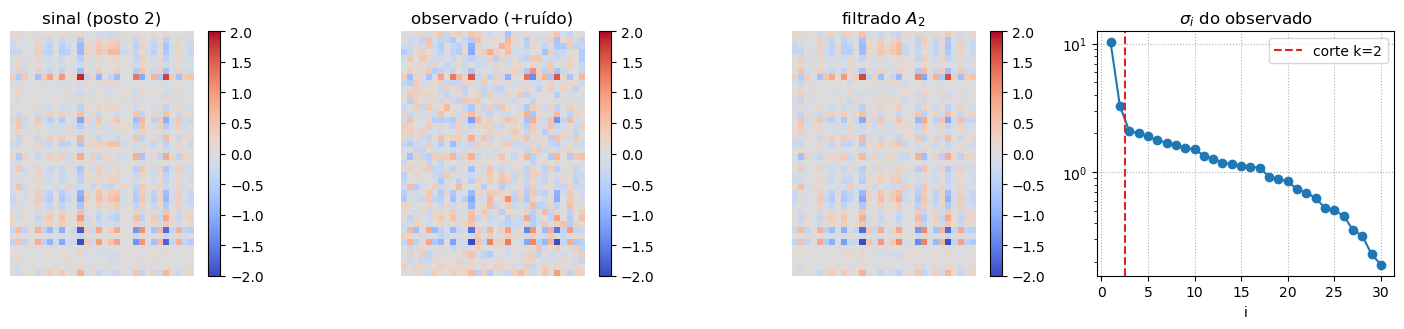

In [11]:
# Visualizar sinal, ruidoso, filtrado e o decaimento dos valores singulares.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

# Os 3 primeiros painéis são mapas de calor das matrizes. zip percorre em paralelo
# (painel, matriz, título) -> a cada volta o "for" desempacota os três numa linha.
matrizes = [A_sinal, A_obs, A2]
titulos  = ["sinal (posto 2)", "observado (+ruído)", "filtrado $A_2$"]
for ax, M, t in zip(axes[:3], matrizes, titulos):
    # imshow desenha a matriz como imagem; vmin/vmax fixam a mesma escala de cor
    # nos três painéis, para a comparação ser justa.
    im = ax.imshow(M, cmap="coolwarm", vmin=-2, vmax=2); ax.set_title(t); ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)   # barra de cores ao lado do painel

# Quarto painel: valores singulares do observado, em semilog.
s_obs = np.linalg.svd(A_obs, compute_uv=False)
axes[3].semilogy(range(1, len(s_obs)+1), s_obs, "o-")
# Linha em x=2.5 marca o corte k=2 (ficamos com os 2 primeiros sigma).
axes[3].axvline(2.5, color="tab:red", ls="--", label="corte k=2")
axes[3].set_title("$\\sigma_i$ do observado"); axes[3].set_xlabel("i"); axes[3].legend(); axes[3].grid(True, ls=":")
plt.tight_layout(); plt.show()

## 8. SVD truncada em uma matriz de snapshots

Cada coluna de $X\in\mathbb{R}^{n\times m}$ é um campo espacial num instante. A truncada dá modos
espaciais $\mathbf{u}_i$ e coeficientes temporais (linhas de $\Sigma_kV_k^T$), com
$\mathbf{x}_j\approx\sum_i a_i(t_j)\mathbf{u}_i$. A **energia modal** mostra quantos modos bastam.

In [12]:
# Snapshots sintéticos: 3 estruturas espaciais com dinâmica temporal + ruído.
n, m = 80, 60                          # n = pontos no espaço, m = instantes de tempo
xg = np.linspace(0, 2*np.pi, n)        # eixo espacial
tg = np.linspace(0, 4*np.pi, m)        # eixo temporal

# Três "formas" no espaço (modos), cada uma com uma frequência diferente.
phi1, phi2, phi3 = np.sin(xg), np.sin(2*xg), np.sin(3*xg)

# Cada np.outer(forma_espacial, evolucao_temporal) cria uma matriz n x m de posto 1:
# a coluna do instante j é a forma espacial multiplicada pelo seu valor temporal em j.
# Somamos três dessas parcelas (com pesos decrescentes) + um ruído fraco.
X = (3.0*np.outer(phi1, np.cos(tg)) +
     1.2*np.outer(phi2, np.sin(tg)) +
     0.4*np.outer(phi3, np.cos(2*tg)) +
     0.05*np.random.randn(n, m))

# A SVD recupera modos espaciais (colunas de U), valores singulares (s) e a parte
# temporal (Vt). Como o dado foi construído com 3 estruturas, esperamos E_3 ~ 1.
U, s, Vt = np.linalg.svd(X, full_matrices=False)
energia = np.cumsum(s**2)/np.sum(s**2)   # energia acumulada (mesma ideia da Seção 4)
print("3 modos preservam E_3 =", round(energia[2], 4), "da energia")
for k in [1, 2, 3]:
    Xk = aproxima_posto(X, k)
    print(f"k={k}: erro relativo = {np.linalg.norm(X-Xk,'fro')/np.linalg.norm(X,'fro'):.3f}")

3 modos preservam E_3 = 0.9992 da energia
k=1: erro relativo = 0.384
k=2: erro relativo = 0.126
k=3: erro relativo = 0.029


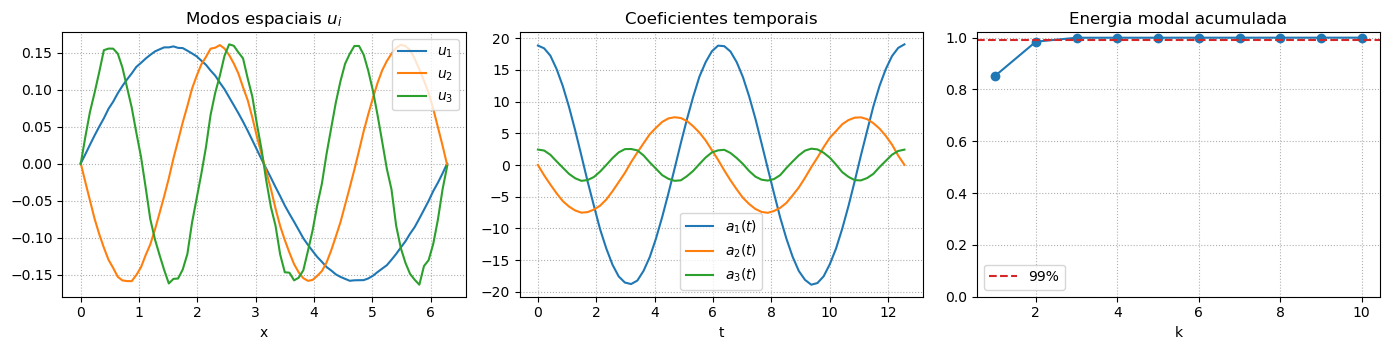

In [13]:
# Modos espaciais, coeficientes temporais e energia modal.
# As notas definem os coeficientes temporais como as linhas de Sigma_k V_k^T.
# np.diag(s) monta a matriz diagonal com os valores singulares; multiplicada por Vt
# dá Sigma V^T, cuja linha i contém os coeficientes a_i(t) ao longo do tempo.
coef = (np.diag(s) @ Vt)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# Painel 1: as 3 formas espaciais dominantes (colunas de U).
for i in range(3):
    axes[0].plot(xg, U[:, i], label=f"$u_{i+1}$")   # U[:, i] = i-ésima coluna de U
axes[0].set_title("Modos espaciais $u_i$"); axes[0].set_xlabel("x"); axes[0].legend(); axes[0].grid(True, ls=":")

# Painel 2: como o peso de cada modo varia no tempo (linhas de coef).
for i in range(3):
    axes[1].plot(tg, coef[i, :], label=f"$a_{i+1}(t)$")   # coef[i, :] = i-ésima linha
axes[1].set_title("Coeficientes temporais"); axes[1].set_xlabel("t"); axes[1].legend(); axes[1].grid(True, ls=":")

# Painel 3: energia acumulada nos 10 primeiros modos (deve saturar perto de 1 cedo).
axes[2].plot(range(1, 11), energia[:10], "o-"); axes[2].axhline(0.99, color="tab:red", ls="--", label="99%")
axes[2].set_title("Energia modal acumulada"); axes[2].set_xlabel("k"); axes[2].set_ylim(0,1.02); axes[2].legend(); axes[2].grid(True, ls=":")
plt.tight_layout(); plt.show()

## Síntese da aula

- A **SVD truncada** $A_k=\sum_{i=1}^k\sigma_i\mathbf{u}_i\mathbf{v}_i^T$ é, por **Eckart–Young**,
  a melhor aproximação de posto $\le k$ em Frobenius e em espectral, com
  $\|A-A_k\|_F^2=\sum_{i>k}\sigma_i^2$ e $\|A-A_k\|_2=\sigma_{k+1}$.
- A **energia acumulada** $E_k$ e o **gap espectral** ajudam a escolher $k$.
- Aplicações imediatas: **compressão** ($k(m+n+1)$ vs $mn$) e **denoising** (sinal baixo posto,
  ruído espalhado). Em **snapshots**, obtemos modos espaciais e coeficientes temporais.

## Limitações a discutir

- Truncar **não** é apagar entradas pequenas: descarta padrões globais $\mathbf{u}_i\mathbf{v}_i^T$.
- A otimalidade é **matricial**, não física: o modo mais energético nem sempre é o mais relevante.
- A SVD **não** distingue física de ruído — denoising é ferramenta, não verdade. Com variância de
  ruído conhecida há limiares ótimos (ex.: **Gavish–Donoho**).
- Decaimento lento de $\sigma$ (sem gap) indica que poucos modos podem não bastar.

## Experimentos sugeridos

1. Refaça os Exercícios 1 ($\operatorname{diag}(6,3,1)$) e 2 ($\sigma=(12,5,2,1)$) numericamente.
2. Aumente o ruído no denoising e observe o ruído "vazar" para os primeiros modos.
3. Estime o armazenamento para $A\in\mathbb{R}^{800\times600}$ com $k=40$ (Exercício 3).
4. Deixe a imagem mais texturizada e veja a compressão piorar.

*Próxima aula (Aula 6): a **PCA** aplica a SVD a dados **centralizados** — os valores singulares
viram variância explicada e os modos viram direções principais.*